<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%202/Q6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Answer For The Question 06

### 1. Shape Parameters

Given:

$$ a=8, \qquad b=20, \qquad c=11 $$

$$ \alpha =1+4\left(\frac{c-a}{b-a}\right) $$

$$ \alpha =1+4\left(\frac{11-8}{20-8}\right) $$

$$ \alpha =1+4\left(\frac{3}{12}\right) $$

$$ \alpha =1+1=2 $$

Similarly,

$$ \beta =1+4\left(\frac{b-c}{b-a}\right) $$

$$ \beta =1+4\left(\frac{20-11}{20-8}\right) $$

$$ \beta =1+4\left(\frac{9}{12}\right) $$

$$ \beta =1+3=4 $$

Therefore,

$$ {\alpha =2,\qquad \beta =4} $$

---

### 2. Support of $X$

The random variable $X$ takes values between $a$ and $b$.

$$ {8 \le X \le 20} $$

Support:

$$ {[8,20]} $$

---

### 3. Probability Density Function

The pdf of the PERT distribution is

$$ f_X(x)=\frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}} $$

Substituting values:

$$ a=8,\quad b=20,\quad \alpha=2,\quad \beta=4 $$

$$ f_X(x)=\frac{(x-8)^{1}(20-x)^3}{B(2,4)(12)^5}, \qquad 8\le x\le20 $$

Thus,

$$ { f_X(x)=\frac{(x-8)(20-x)^3}{B(2,4)12^5}, \quad 8\le x\le20 } $$

and

$$ f_X(x)=0,\qquad \text{otherwise} $$

---

### 4. Probability Space

A suitable probability space is

$$ { (\Omega,\mathfrak F,P) } $$

where

$$ \Omega=[8,20] $$

$$ \mathfrak F=\text{Borel sigma algebra on }[8,20] $$

and $P$ is the probability measure defined by

$$ P(A)=\int_A f_X(x) dx $$

for all $A\in\mathfrak F$.

---

### 5. Definition of Random Variable

Define

$$ X:\Omega\to \mathbb R $$

by

$$ {X(\omega)=\omega,\qquad \omega\in[8,20]} $$

Hence $X$ is a continuous random variable with PERT density $f_X(x)$.

---

### 6. Expectation of $X$

For a PERT distribution,

$$ E[X]=\frac{a+4c+b}{6} $$

Substituting values:

$$ E[X]=\frac{8+4(11)+20}{6} $$

$$ E[X]=\frac{8+44+20}{6} $$

$$ E[X]=\frac{72}{6} $$

$$ {E[X]=12\text{ days}} $$

---

### 7. Variance

Using

$$ \mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7} $$

Substitute values:

$$ \mathrm{Var}(X)=\frac{(12-8)(20-12)}{7} $$

$$ =\frac{(4)(8)}{7} $$

$$ =\frac{32}{7} $$

$$ {\mathrm{Var}(X)\approx 4.57} $$

---

### 8. Standard Deviation

$$ \sigma=\sqrt{\mathrm{Var}(X)} $$

$$ \sigma=\sqrt{\frac{32}{7}} $$

$$ \sigma\approx 2.14 $$

Therefore,

$$ {\sigma \approx 2.14\text{ days}} $$

---

### 9. Why PERT Distribution is More Appropriate

*   The PERT distribution gives more weight to the most likely value ($c$).
*   It produces a smoother and more realistic curve than the Triangular distribution.
*   The Triangular distribution has sharp corners and assumes linear behavior.
*   PERT is better for project planning because task durations are usually concentrated around the most likely value.

---

### 10. Practical Interpretation

*   $a=8$: minimum possible completion time.
*   $b=20$: maximum possible completion time.
*   $c=11$: most likely completion time.
*   $E[X]=12$: expected average completion time of the task.
*   $\sigma\approx2.14$: measures uncertainty or variability in completion time. Smaller $\sigma$ means more predictable task duration.

Plot of the triangle and PERT distributions

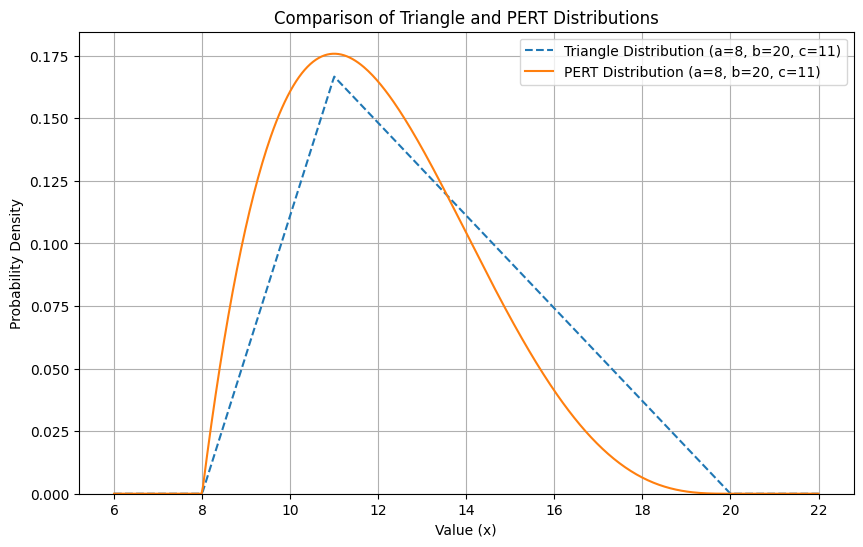

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist # Renamed import to avoid conflict

# Parameters from the notebook
a = 8
b = 20
c = 11

# PERT distribution parameters (alpha, beta calculated in the notebook)
alpha_pert = 2
beta_pert = 4

# Define the Triangle Distribution PDF
def triangle_pdf(x, a, b, c):
    if a <= x <= c:
        return 2 * (x - a) / ((b - a) * (c - a))
    elif c < x <= b:
        return 2 * (b - x) / ((b - a) * (b - c))
    else:
        return 0

# Define the PERT Distribution PDF
def pert_pdf(x, a, b, alpha, beta_shape_param): # Renamed parameter
    if a <= x <= b:
        # Scale and shift x for the beta distribution
        y = (x - a) / (b - a)
        # Calculate the PDF of the beta distribution
        return beta_dist.pdf(y, alpha, beta_shape_param) / (b - a) # Using renamed import
    else:
        return 0

# Generate x values for the plot
x_values = np.linspace(a - 2, b + 2, 500) # Extend range slightly for visualization

# Calculate PDF values for both distributions
triangle_y = [triangle_pdf(x, a, b, c) for x in x_values]
pert_y = [pert_pdf(x, a, b, alpha_pert, beta_pert) for x in x_values]

# Plot the distributions
plt.figure(figsize=(10, 6))
plt.plot(x_values, triangle_y, label='Triangle Distribution (a=8, b=20, c=11)', linestyle='--')
plt.plot(x_values, pert_y, label='PERT Distribution (a=8, b=20, c=11)', linestyle='-')

plt.title('Comparison of Triangle and PERT Distributions')
plt.xlabel('Value (x)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts from 0
plt.show()